# **Imports and file reading**

In [ ]:
import pandas as pd
import seaborn as sns


from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [3]:
df = pd.read_csv("../../../Data/loan.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# **information about dataset**

In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [6]:
# df["Married"] = df["Married"].fillna("unknown")
# df["Gender"] = df["Gender"].fillna("unknown")
# df["Dependents"] = df["Dependents"].str.replace("+","").fillna(-1).astype("int", errors="ignore")
# df["Education"] = df["Education"]

# df["Dependents"].unique()

In [7]:
Q1 = df["ApplicantIncome"].quantile(0.25)
Q3 = df["ApplicantIncome"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

df = df[(lower <= df["ApplicantIncome"] ) & (upper >= df["ApplicantIncome"]) ]

In [8]:
Q1 = df["CoapplicantIncome"].quantile(0.25)
Q3 = df["CoapplicantIncome"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

df = df[(lower <= df["CoapplicantIncome"] ) & (upper >= df["CoapplicantIncome"]) ]

# **Segreation of columns**

In [9]:
df.drop(columns="Loan_ID", inplace=True, errors="ignore")
df["Dependents"] = df["Dependents"].str.replace("+","").fillna(-1).astype("int", errors="ignore")

X = df.drop(columns="Loan_Status")
y = df["Loan_Status"]

# **Train test split**

In [10]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=42)

In [11]:

num_col = Xtrain.select_dtypes(include="number").columns
cat_col = Xtrain.select_dtypes(include="object").columns


C:\Users\MAYURESHWAR\AppData\Local\Temp\ipykernel_5720\4185918253.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = Xtrain.select_dtypes(include="object").columns


# **Data valuation**

In [12]:
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit and transform the training data
Xtrain[num_col] = num_imputer.fit_transform(Xtrain[num_col])
Xtrain[cat_col] = cat_imputer.fit_transform(Xtrain[cat_col])

# Transform the test data using the rules learned from the training data
Xtest[num_col] = num_imputer.transform(Xtest[num_col])
Xtest[cat_col] = cat_imputer.transform(Xtest[cat_col])

In [13]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


<Axes: >

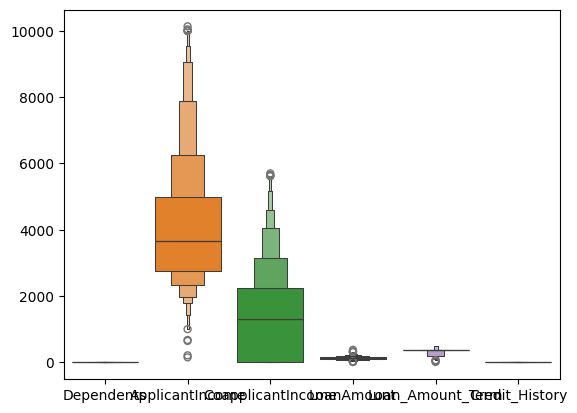

In [14]:
sns.boxenplot(df)

# **Pre-processing**

In [15]:
preprocessing = ColumnTransformer(
    transformers=[
        ("cat_onehot", OneHotEncoder(handle_unknown="ignore"), ["Gender", "Married"]),
        (
            "cat_ordinal",
            OrdinalEncoder(
                categories=[
                    ["Not Graduate", "Graduate"],  # Order for Education
                    ["No", "Yes"],                  # Order for Self_Employed
                    ['Rural','Semiurban','Urban'  ]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            ["Education", "Self_Employed", "Property_Area"]
        ),
        ("Sc",StandardScaler(), ["Dependents",	"ApplicantIncome",	"CoapplicantIncome",	"LoanAmount",	"Loan_Amount_Term",	"Credit_History"])
    ],
    remainder="passthrough"  # Keeps other columns in the DataFrame
)


In [16]:
main_pipeline = Pipeline(
    steps=[
        ("pre", preprocessing),
        ("model", KNeighborsClassifier(n_neighbors=7, weights='uniform'))
    ]
)

In [17]:
main_pipeline.fit(Xtrain, ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_onehot', ...), ('cat_ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [18]:
y_train_pred = main_pipeline.predict(Xtrain)
y_test_pred = main_pipeline.predict(Xtest)

In [19]:
print(classification_report(ytrain, y_train_pred))

              precision    recall  f1-score   support

           N       0.87      0.50      0.63       133
           Y       0.81      0.97      0.88       305

    accuracy                           0.82       438
   macro avg       0.84      0.73      0.76       438
weighted avg       0.83      0.82      0.81       438



In [20]:
print(classification_report(ytest, y_test_pred))

              precision    recall  f1-score   support

           N       0.94      0.49      0.64        35
           Y       0.80      0.99      0.89        75

    accuracy                           0.83       110
   macro avg       0.87      0.74      0.76       110
weighted avg       0.85      0.83      0.81       110



In [21]:
confusion_matrix(ytest,y_test_pred )

array([[17, 18],
       [ 1, 74]])